### Run DLC example
In this example we load data from our DLC observation logs to determine the offset positions of the star on the fiber to run. Then we run dlc_package to compute the expected velocities at each offset position

### Step 1. Import packages

In [1]:
import numpy as np
import matplotlib.pylab as plt
from pathlib import Path
import sys
import astropy.units as u

plt.ion()
# just for the notebook, can remove if running as a script
%matplotlib widget


# optional yaml file could feed
config_path = "/dlc_package/configs/gen_config.yaml"

file_path = '/Users/ashleybaker/Documents/DLC/'
sys.path.insert(0, str(Path(file_path) / "dlc_package"))
from obsdata_utils import cObsLog
from dlc import DifferentialLimbCoupling as dlc_class


### Step 2a. Load the Observation information
Use the observation log package (cObsLog) to load the observing logs and select the target and date of observations we want. 

In [2]:
############ PARAMS
target = 'MuGem'
date = '20250227'
data_path = f'/Users/ashleybaker/Documents/DLC/_data/{target}/'
observation_log_file = str(Path(file_path, "_data/PARVIRVBiasObservationSummary.xlsx"))
##############

# Load MuGem Supporting Data - obslog
# pass target so only this target's rows are loaded, the obs log holds all targets
obslog = cObsLog(observation_log_file, data_path, target=target)
obslog.select_by_date(date) # data stored in obslog.obs_data_subset 


warning, could not calculate BC or PA for file /Users/ashleybaker/Documents/DLC/_data/MuGem/MuGem_R01_20251016105733_deg0_sp.fits, setting to nan for this observation
Cannot create a SkyCoord without data
warning, could not calculate BC or PA for file /Users/ashleybaker/Documents/DLC/_data/MuGem/MuGem_R01_20251016110215_deg0_sp.fits, setting to nan for this observation
Cannot create a SkyCoord without data
warning, could not calculate BC or PA for file /Users/ashleybaker/Documents/DLC/_data/MuGem/MuGem_R01_20251016110446_deg0_sp.fits, setting to nan for this observation
Cannot create a SkyCoord without data
warning, could not calculate BC or PA for file /Users/ashleybaker/Documents/DLC/_data/MuGem/MuGem_R02_20251016110446_deg0_sp.fits, setting to nan for this observation
Cannot create a SkyCoord without data
warning, could not calculate BC or PA for file /Users/ashleybaker/Documents/DLC/_data/MuGem/MuGem_R03_20251016110446_deg0_sp.fits, setting to nan for this observation
Cannot create

In [3]:
print(obslog.obs_data_subset.xpos_meas)

0     -99.000000
1     -99.000000
2     -99.000000
3     -99.000000
4     -99.000000
         ...    
141    14.551852
142    14.551852
143    15.420933
144    15.420933
145    15.420933
Name: xpos_meas, Length: 146, dtype: float64


### Step 2b. Format the Offsets
Edit the offsets to be in the units we need and defined relative to the center - this can be moved to the obs log package

In [4]:
# define x, y offsets. theta is unknown for now so run a few
guide_platescale = 36.7 # mas/pix, from guide camera analysis, should add to obsdata utils

# Here we modify the offsets to be relative to the center, 0,0 and to be in the right units for the DLC package (mas)
# if guiding not existent, will populate with -99. Exclude these
ifinite = np.where((obslog.obs_data_subset.xpos_meas > -99) & (obslog.obs_data_subset.ypos_meas > -99))[0] # check that all offsets are in the same quadrant, if not need to flip signs
xoffsets = guide_platescale * (obslog.obs_data_subset.xpos_meas.values[ifinite]) # found centers from plot, should really store this though
yoffsets = guide_platescale * (obslog.obs_data_subset.ypos_meas.values[ifinite])

mjds = obslog.obs_data_subset.obstime_bjd.values[ifinite]

icentered = np.where((obslog.obs_data_subset.xpos.values[ifinite] ==0) & (obslog.obs_data_subset.ypos.values[ifinite]==0))[0]
xcent = np.mean(obslog.obs_data_subset.xpos_meas.values[ifinite][icentered])
ycent = np.mean(obslog.obs_data_subset.ypos_meas.values[ifinite][icentered])

# subtract off the 0,0 position so we just have relative offset from fiber
xoffsets -= guide_platescale * xcent # mas/pix
yoffsets -= guide_platescale * ycent # mas/pix

# make these unique..
iunique = np.sort(np.unique(xoffsets, return_index=True)[1]).astype(int) # unique offsets to run, should be 4 for the 4 quadrants, but check that they are all in the same quadrant first
print(len(iunique))

31


### Step 3. Run DLC
Now that we have the offsets we can run the DLC pacakge to determine the corresponding velocities expected for our system

In [6]:
# Start dlc simulation
# offsets reach 66 mas so the map has to be bigger than the 50 mas default, otherwise
# the coupling map wraps around and the far offsets are garbage
dlcc = dlc_class(diagnostics_on=False, 
                 config=dict(xoffsets = xoffsets,
                             yoffsets = yoffsets,
                             theta=70 * u.deg, 
                             vsini=8.4 * u.km/u.s, 
                             R=70000, 
                             diameter=15.0 * u.mas,
                             coupling_map_boundary=70 * u.mas,
                             telescope='Palomar'))

dlcc.run()


/Users/ashleybaker/Documents/DLC/dlc_package/dlc.py:240: UserWarning: Loading Keck coupling map for Palomar/Hale in yJ band, - scaling plate scale to match Palomar since using Keck coupling map, should make a Palomar specific coupling map in the future
  warnings.warn('Loading Keck coupling map for Palomar/Hale in yJ band, - scaling plate scale to match Palomar since using Keck coupling map, should make a Palomar specific coupling map in the future')


Loading /Users/ashleybaker/Documents/DLC/dlc_package/data/coupling_maps/staticModel_Keck_yJ_defoc0nmRMS_LO0nmRMS_Fnum3.67_atm0_adc0_nWvls10_PL0.fits
vel slope 0.09326725758 km / s
res vel 4282.7 m / s spec kernel wid 183676.4 m pix / km
Running x,y position 20.62759297337709 mas -2.4120933588285425 mas
vel -0.07461552877305355 km / s
Running x,y position 20.62759297337709 mas -2.4120933588285425 mas
vel -0.07461552877305355 km / s
Running x,y position 20.62759297337709 mas -2.4120933588285425 mas
vel -0.07461552877305355 km / s
Running x,y position 20.62759297337709 mas -2.4120933588285425 mas
vel -0.07461552877305355 km / s
Running x,y position 20.62759297337709 mas -2.4120933588285425 mas
vel -0.07461552877305355 km / s
Running x,y position 34.984864269666105 mas -2.402401250635421 mas
vel -0.11769148762176661 km / s
Running x,y position 34.984864269666105 mas -2.402401250635421 mas
vel -0.11769148762176661 km / s
Running x,y position 34.984864269666105 mas -2.402401250635421 mas
vel

### Step 4. Plot!
Lots of plots to make and save...

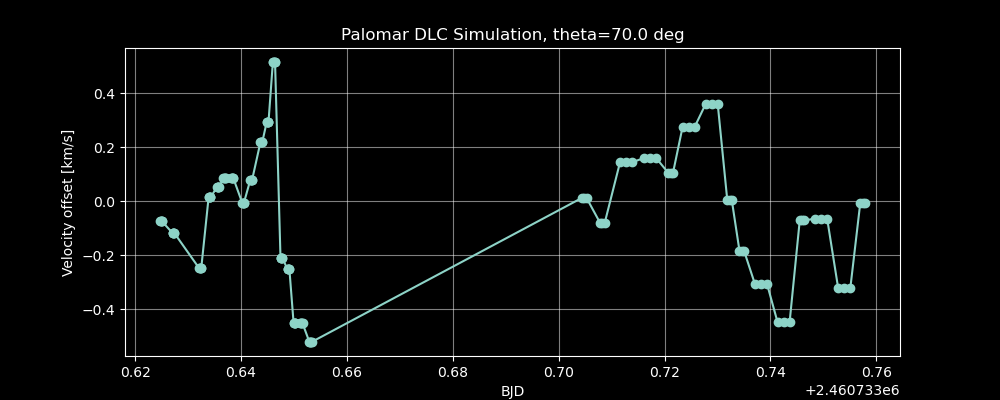

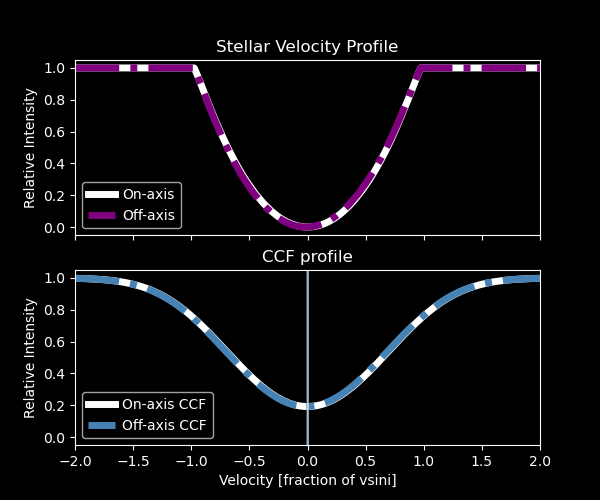

In [10]:
#dlcc.printSettings()
save_path = './'
file_name = f'{target}_{date}_DLC_simulation_theta{dlcc.theta.value}_vsini{dlcc.vsini.value}_R{dlcc.R}'

#dlcc.plot_star_fiber(save_path = save_path + file_name + '_star_fiber.png')
dlcc.plot_rvs(mjds, xlabel= 'BJD', save_path = save_path + file_name + '_rvs.png')

dlcc.plot_lsf_ccf(save_path = save_path + file_name + '_lsf_ccf.png')


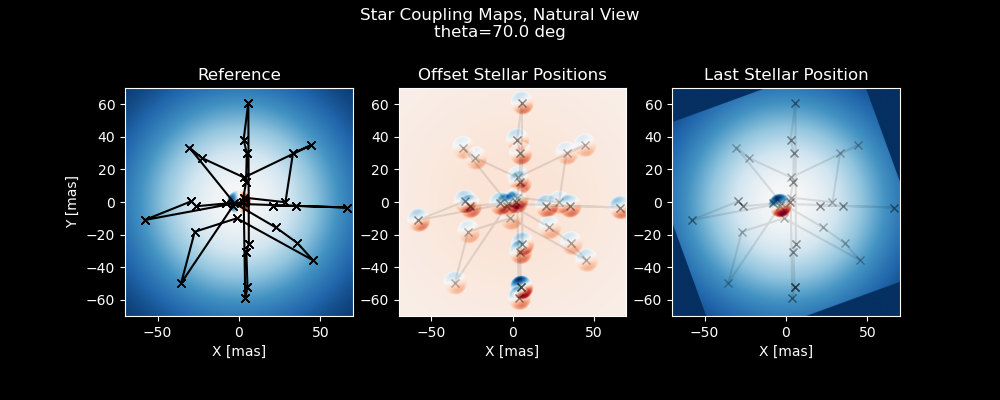

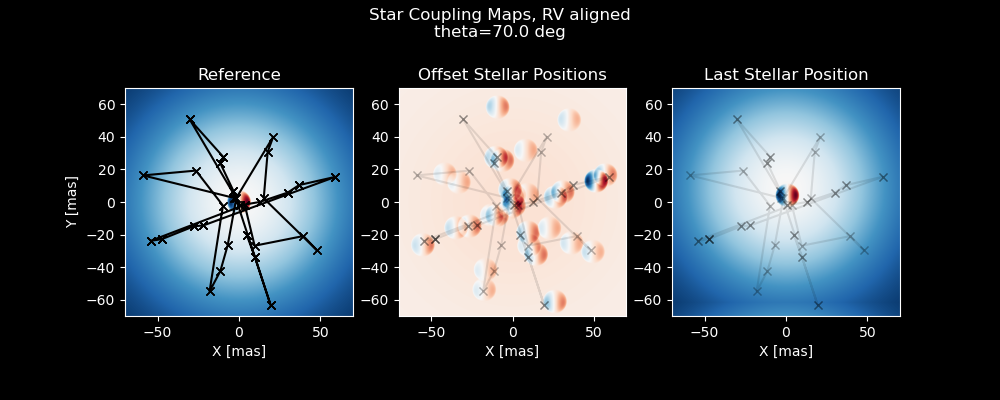

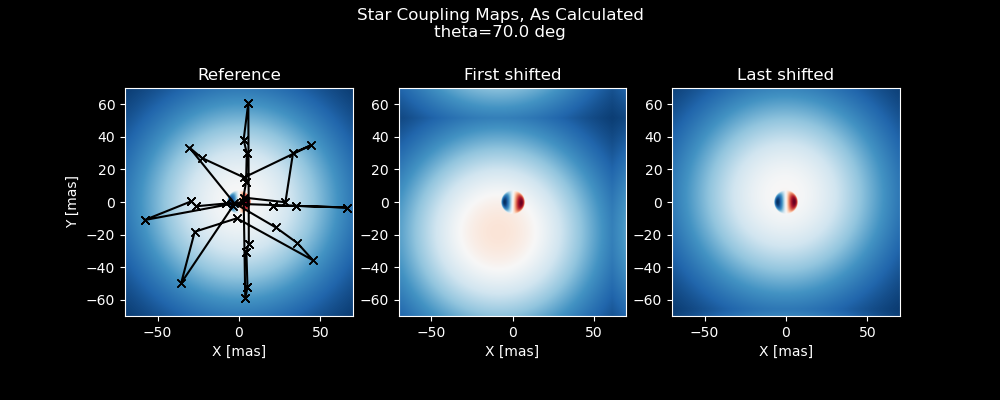

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

ValueError: Quantity truthiness is ambiguous, especially for logarithmic units and temperatures. Use explicit comparisons.

In [12]:
dlcc.plot_star_fiber()
dlcc.plot_star_fiber_RValigned()
dlcc.plot_star_fiber_raw()

# Next Steps
- provide output path where will save the plots
- next feed it mu gem offsets and parameters, make a mugem config perhaps
- then add tt jitter
- then add DAR effects